# 4.2. The Image Classification Dataset
D2L의 The Image Classification Dataset장을 PyTorch 기준으로 정리함.

이번 장에서는 Fashion-MNIST 이미지 데이터를 PyTorch로 불러오고,
모델이 학습할 수 있는 minibatch 형태로 만드는 방법을 공부한다.

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [ ]:
%matplotlib inline

import time # 데이터 읽기 시간 측정용

import matplotlib.pyplot as plt # 이미지 출력용
import torch
from torch.utils.data import DataLoader # 데이터를 minibatch단위로 가져옴
from torchvision import datasets, transforms
# datasets = Fashion-MNIST같은 이미지 데이터 셋 제공
# transforms 이미지를 Tensor로 변환하거나 크기 변경

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. MNIST와 Fashion-MNIST

MNIST는 손으로 쓴 숫자 이미지를 분류하는 데이터셋이다.

예를 들어서 이런 이미지를 보고 숫자를 맞히는 문제다.

- 숫자 0 이미지 -> label 0
- 숫자 1 이미지 -> label 1
- 숫자 9 이미지 -> label 9

MNIST는 과거에 어려운 문제였지만, 현재는 간단한 모델도 높은 정확도를
낼 수 있어서 모델 성능을 제대로 비교하기에 너무 쉬운 데이터셋이 되었다.

그래서 D2L은 MNIST 대신 Fashion-MNIST를 사용한다.

Fashion-MNIST는 숫자가 아니고 옷 종류를 분류한다.

- 티셔츠
- 바지
- 스웨터
- 원피스
- 코트
- 샌들
- 셔츠
- 운동화
- 가방
- 앵클부츠

Fashion-MNIST는 10개 의류 범주로 구성되고, 원본 이미지는 28 × 28 크기의 흑백 이미지이다. 훈련 데이터는 60,000개, 테스트 데이터는 10,000개이다.

D2L에선 기존 MNIST보다 조금 더 현실적인 분류 연습용 데이터로 Fashion-MNIST를 사용한다.

| 구분 | 이미지 개수 | 용도 |
|---|---:|---|
| Training set | 60,000개 | 모델 학습 |
| Test set | 10,000개 | 학습이 끝난 모델 평가 |

각 class마다 다음과 같이 구성되어 있다.

- Training set: class당 6,000개
- Test set: class당 1,000개
- 전체 class 수: 10개

D2L 코드에는 테스트 데이터를 val이라는 이름으로 저장합니다. 하지만 Fashion-MNIST가 기본으로 제공하는 것은 train=True 훈련 split과 train=False 테스트 split이다.

엄밀한 실험이라면 훈련 데이터 일부를 validation set으로 따로 분리하고, test set은 최종 평가에만 사용하는 것이 맞다고 한다.

## 3. 이미지 변환 정의하기

Fashion-MNIST에서 가져온 원본 이미지는 바로 모델에 넣지 않고
먼저 PyTorch Tensor로 변환해야 한다.

`transforms.ToTensor()`는 이미지를 Tensor로 변환한다.

변환 전 이미지의 구조:

`[height, width]`

변환 후 이미지의 구조:

`[channel, height, width]`

Fashion-MNIST는 흑백 이미지이므로 channel 수가 1이다.

따라서 이미지 하나의 shape은 다음과 같다.

`[1, 28, 28]`

또한 픽셀값은 일반적으로 0~255 범위에서 0.0~1.0 범위의 float 값으로 변환된다.

이미지 한 장도 Tensor이다.
1 = channel 수, 28 = 이미지 높이, 28 = 이미지 너비

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

## 4. Fashion-MNIST 불러오기

`datasets.FashionMNIST()`는 Fashion-MNIST 데이터셋을 내려받고
PyTorch에서 사용할 수 있도록 Dataset 객체로 만들어준다.

각 인자의 의미는 다음과 같다.

- `root="./data"`  
  데이터를 저장할 폴더이다.

- `train=True`  
  Training set 60,000개를 불러온다.

- `train=False`  
  Test set 10,000개를 불러온다.

- `transform=transform`  
  이미지를 가져올 때 앞에서 정의한 변환을 적용한다.

- `download=True`  
  데이터가 없다면 인터넷에서 내려받는다.

In [3]:
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

100.0%
100.0%
100.0%
100.0%


In [4]:
print("훈련 데이터 개수:", len(train_dataset))
print("테스트 데이터 개수:", len(test_dataset))

훈련 데이터 개수: 60000
테스트 데이터 개수: 10000


## 5. Dataset이란 무엇인가

Dataset은 데이터 전체를 관리하면서, 특정 index의 데이터 하나를 가져올 수 있도록 만든 객체이다.

예를 들어서 이코드는 첫 번째 데이터를 가져온다. train_dataset[0]

이미지 분류 Dataset에서 데이터 하나는 일반적으로 이렇게 구성된다.

(image, label)

- `image`: 입력 이미지 Tensor
- `label`: 이미지의 정답 class 번호

In [5]:
sample = train_dataset[0]

print(type(sample))
print(len(sample))

<class 'tuple'>
2


In [ ]:
image, label = train_dataset[0]

print("image type:", type(image))
print("image shape:", image.shape) # 이미지 Tensor
print("image dtype:", image.dtype)

print("label:", label)             # 이미지 정답 class 번호
print("label type:", type(label))

# 이 이미지는 class 9에 해당한다.

image type: <class 'torch.Tensor'>
image shape: torch.Size([1, 28, 28])
image dtype: torch.float32
label: 9
label type: <class 'int'>


## 6. Feature와 Label 연결하기

전에 배웠던 개념과 연결해보면
image = X에 해당하는 입력 feature
label = y에 해당하는 정답이다.

선형회귀에서는 입력과 정답을 다음처럼 표현했다.

    X = 입력 feature
    y = 정답

이미지 분류에서도 기본 구조는 같다.

    X = 이미지
    y = 이미지의 class 번호

예를 들어:

    X = 앵클부츠 이미지
    y = 9

모델은 이미지를 입력받아서 각 class에 대한 점수를 계산하고,
가장 가능성이 높은 class를 예측하게 된다.

## 7. 이미지 픽셀값 확인하기

이미지는 숫자로 구성되어 있다.

흑백 이미지에서 각 숫자는 해당 위치의 밝기를 나타낸다.

- 0에 가까울수록 어두운 픽셀
- 1에 가까울수록 밝은 픽셀

`ToTensor()`를 사용했기 때문에 이미지의 픽셀값은
대체로 0.0부터 1.0 사이의 값으로 변환되어 있다.

따라서 모델은 실제로 옷이나 사진을 직접 보는 것이 아니다.
이미지를 구성하는 픽셀 숫자들을 입력받는다.

In [8]:
print("최솟값:", image.min())
print("최댓값:", image.max())

print(image[0, :5, :5])

최솟값: tensor(0.)
최댓값: tensor(1.)
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


## 8. 이미지 출력하기

`image`의 원래 shape은 다음과 같다.

    [1, 28, 28]

하지만 matplotlib으로 흑백 이미지를 출력할 때는 보통 다음 shape을 사용한다.

    [28, 28]

따라서 `squeeze(0)`을 사용해서 크기가 1인 channel 차원을 제거한다.

    [1, 28, 28]
          ↓ squeeze(0)
    [28, 28]

여기서 이미지 데이터 자체가 사라지는 것은 아니다.
불필요한 크기 1짜리 차원만 제거한다.

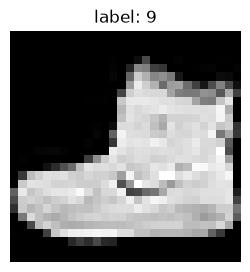

In [9]:
plt.figure(figsize=(3, 3))

plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"label: {label}")
plt.axis("off")

plt.show()

## 9. 숫자 Label을 옷 이름으로 변환하기

Fashion-MNIST의 label은 이렇다.

| Label | Class |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

컴퓨터는 `Ankle boot`라는 문자열 대신 숫자 9를 정답으로 사용한다.

숫자는 모델의 loss를 계산하고 Tensor 연산을 수행하기 편하기 때문이다.
사람이 결과를 확인할 때만 숫자를 실제 class 이름으로 바꿔서 출력한다.

숫자 label: 9
실제 class: Ankle boot


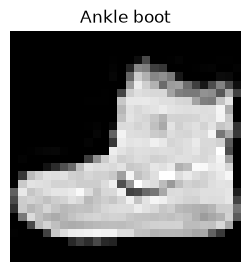

In [12]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("숫자 label:", label)
print("실제 class:", class_names[label])

plt.figure(figsize=(3, 3))

plt.imshow(image.squeeze(0), cmap="gray")
plt.title(class_names[label])
plt.axis("off")

plt.show()

## 10. Resize 사용하기

D2L은 이미지 크기를 32 × 32로 변경하는 예시도 보여준다. 원본 Fashion-MNIST는 28 × 28이지만 Resize를 적용하면 [1, 32, 32]가 된다.

In [ ]:
resize_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

resized_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=resize_transform,
    download=True
)

resized_image, resized_label = resized_train_dataset[0]

print("원래 이미지 shape:", image.shape)
print("크기를 변경한 이미지 shape:", resized_image.shape)

원래 이미지 shape: torch.Size([1, 28, 28])
크기를 변경한 이미지 shape: torch.Size([1, 32, 32])


## 11. DataLoader 만들기

Dataset은 데이터 하나를 가져오는 역할을 한다.

    train_dataset[0]

DataLoader는 Dataset에서 여러 데이터를 꺼내서
minibatch 단위로 묶어 주는 역할을 한다.

    이미지 64개 + 정답 64개

각 인자의 의미는 다음과 같다.

- `dataset=train_dataset`
  - 어떤 Dataset에서 데이터를 가져올지 지정한다.

- `batch_size=64`
  - 한 번에 이미지 64개를 가져온다.

- `shuffle=True`
  - 매 epoch마다 훈련 데이터의 순서를 무작위로 섞는다.

- `num_workers=0`
  - 현재 Python 프로세스에서 데이터를 불러온다.

In [14]:
batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

## 12. 왜 훈련 데이터만 Shuffle하나

훈련 데이터는 일반적으로 `shuffle=True`를 사용한다.

데이터가 항상 같은 순서로 들어가면 모델이 데이터 순서의 영향을
받을 수 있기 때문이다.

훈련할 때마다 데이터 순서를 섞으면 minibatch 구성이 달라지고,
모델이 특정 데이터 순서에 지나치게 의존하는 것을 줄일 수 있다.

test set은 학습하지 않고 평가만 한다.

따라서 일반적으로 다음과 같이 설정한다.

    train_loader: shuffle=True
    test_loader: shuffle=False

shuffle은 샘플이 나오는 순서만 섞는 것이다.

## 13. Minibatch 하나 가져오기

이미지 batch의 shape은 다음과 같다.

    X.shape = [64, 1, 28, 28]

각 숫자의 의미는 다음과 같다.

    [batch_size, channel, height, width]

즉:

- 64: 이미지 개수
- 1: 흑백 channel 수
- 28: 이미지 높이
- 28: 이미지 너비

정답 batch의 shape은 다음과 같다.

    y.shape = [64]

이미지가 64개이므로 각 이미지에 대응하는 정답도 64개이다.

In [ ]:
X, y = next(iter(train_loader))

print("X shape:", X.shape) # [이미지 개수, channel수, 높이, 너비]
print("X dtype:", X.dtype)

print("y shape:", y.shape) # 이미지 개수에 맞게 정답도 64
print("y dtype:", y.dtype)

X shape: torch.Size([64, 1, 28, 28])
X dtype: torch.float32
y shape: torch.Size([64])
y dtype: torch.int64


## 14. Label은 One-hot Vector가 아니다.

`y`에는 각 이미지의 class 번호가 들어 있다.

예를 들어:

    tensor([9, 0, 3])

의 의미는 다음과 같다.

- 첫 번째 이미지: class 9
- 두 번째 이미지: class 0
- 세 번째 이미지: class 3

label은 다음과 같은 one-hot vector가 아니다.

    class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

PyTorch의 classification loss는 일반적으로
정답 class 번호를 직접 받기 때문에 다음처럼 저장한다.

    class 3 → 3

In [16]:
print(y[:10])

tensor([0, 2, 8, 1, 8, 1, 5, 7, 6, 1])


## 15. Batch안 이미지 출력하기

`X[i]`는 batch 안의 i번째 이미지를 가져온다.

    X.shape    = [64, 1, 28, 28]
    X[i].shape = [1, 28, 28]

`X[i].squeeze(0)`을 적용하면 다음과 같이 바뀐다.

    [1, 28, 28] → [28, 28]

`y[i]`는 Tensor이므로 Python 정수로 사용하려면
`.item()`을 호출할 수 있다.

    y[i]          → tensor(9)
    y[i].item()   → 9

따라서 다음 코드로 class 이름을 구한다.

    class_names[y[i].item()]

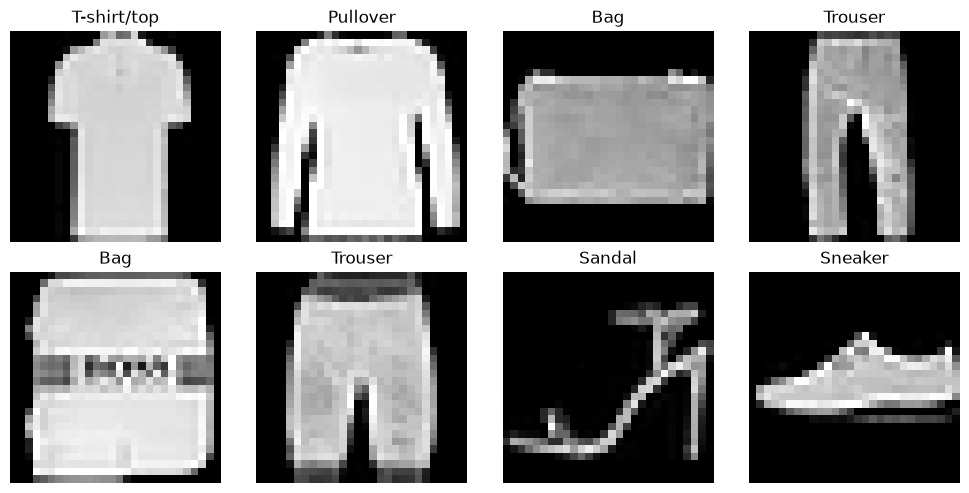

In [17]:
num_images = 8

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i in range(num_images):
    axes[i].imshow(X[i].squeeze(0), cmap="gray")
    axes[i].set_title(class_names[y[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 16. 전체 minibatch와 마지막 batch 확인하기

In [19]:
batch_count = 0
image_count = 0

for X_batch, y_batch in train_loader:
    batch_count += 1
    image_count += X_batch.shape[0]

print("전체 batch 개수:", batch_count) # 전체 이미지 개수 ÷ 64 = 937.5
print("전체 이미지 개수:", image_count)

last_X = None
last_y = None

for last_X, last_y in train_loader:
    pass

print("마지막 X shape:", last_X.shape)
print("마지막 y shape:", last_y.shape)

전체 batch 개수: 938
전체 이미지 개수: 60000
마지막 X shape: torch.Size([32, 1, 28, 28])
마지막 y shape: torch.Size([32])


## 17. drop_last?

Dataset 크기가 batch size로 정확히 나누어지지 않으면
마지막 batch는 다른 batch보다 작을 수 있다.

현재 설정에서는:

    전체 데이터: 60,000개
    batch size: 64
    마지막 batch: 32개

기본 설정인 `drop_last=False`는 마지막 작은 batch도 사용한다.

`drop_last=True`를 지정하면 마지막 작은 batch를 버린다.

In [20]:
drop_last_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("기본 DataLoader batch 개수:", len(train_loader))
print("drop_last=True batch 개수:", len(drop_last_loader))

기본 DataLoader batch 개수: 938
drop_last=True batch 개수: 937


## 18. 데이터 읽기 속도 측정

모델 학습 중에는 이런 작업이 반복된다.

1. DataLoader가 데이터를 읽는다.
2. 이미지 전처리를 수행한다.
3. minibatch를 만든다.
4. 모델에 전달한다.
5. forward와 backward를 수행한다.

데이터를 읽는 속도가 너무 느리면 GPU가 계산을 끝내고도 다음 데이터를 기다려야 한다.

이런 상태를 I/O bottleneck이라고 한다.

Fashion-MNIST는 매우 작은 데이터셋이므로
현재 실습에서는 DataLoader 성능을 심하게 최적화할 필요는 없다.

D2L에선 데이터 iterator가 학습 루푸의 구성 요소이고, 데이터 읽기가 지나치게 느리면 전체 학습이 제한될 수 있다고 설명했다.

In [ ]:
start = time.time()

total_images = 0

for X_batch, y_batch in train_loader:
    total_images += X_batch.shape[0]

elapsed = time.time() - start

print("읽은 이미지 수:", total_images)
print(f"걸린 시간: {elapsed:.2f}초")

읽은 이미지 수: 60000
걸린 시간: 27.71초


## 19. Batch size에 따른 속도 비교하기

batch size가 1이면 이미지 한 장마다 DataLoader가 batch를 만들어야 한다.

전체 이미지가 60,000개라면:

    batch_size=1   → 60,000번 반복
    batch_size=64  → 약 938번 반복
    batch_size=256 → 약 235번 반복

batch size가 작으면 한 번에 처리하는 데이터가 적어지고,
Python 반복문과 데이터 전달 횟수가 증가한다.

따라서 일반적으로 batch size가 1일 때 데이터 전체를 읽는 시간이
더 길어질 가능성이 크다.

하지만 실제 측정 시간은 CPU, 저장장치, 운영체제,
캐시 상태와 num_workers 설정에 따라 달라진다.

In [22]:
def measure_loading_time(dataset, batch_size):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    start = time.time()

    total_images = 0

    for X_batch, y_batch in loader:
        total_images += X_batch.shape[0]

    elapsed = time.time() - start

    return {
        "batch_size": batch_size,
        "num_batches": len(loader),
        "num_images": total_images,
        "elapsed": elapsed
    }

for batch_size in [1, 16, 64, 256]:
    result = measure_loading_time(train_dataset, batch_size)

    print(
        f"batch_size={result['batch_size']:>3}, "
        f"batch 수={result['num_batches']:>5}, "
        f"시간={result['elapsed']:.3f}초"
    )

batch_size=  1, batch 수=60000, 시간=64.485초
batch_size= 16, batch 수= 3750, 시간=25.813초
batch_size= 64, batch 수=  938, 시간=19.519초
batch_size=256, batch 수=  235, 시간=17.863초


## 20. D2L 원본 코드 보기

### transforms.Compose

여러 이미지 변환을 순서대로 묶는다.

    transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor()
    ])

처리 순서는 다음과 같다.

    원본 이미지
    → 지정한 크기로 변경
    → PyTorch Tensor로 변환

### train=True

Fashion-MNIST의 훈련 데이터 60,000개를 불러온다.

### train=False

Fashion-MNIST의 테스트 데이터 10,000개를 불러온다.

D2L은 이 데이터를 `self.val`에 저장하지만,
실제로는 Fashion-MNIST의 test split이다.

### transform=trans

Dataset에서 이미지를 가져올 때마다 변환을 적용한다.

### download=True

데이터 파일이 없다면 자동으로 내려받는다.

In [ ]:
trans = transforms.Compose([
    transforms.Resize(resize),
    transforms.ToTensor()
])

self.train = torchvision.datasets.FashionMNIST(
    root=self.root,
    train=True,
    transform=trans,
    download=True
)

self.val = torchvision.datasets.FashionMNIST(
    root=self.root,
    train=False,
    transform=trans,
    download=True
)

## 21. 전체 데이터흐름

Fashion-MNIST가 모델에 들어가기 전까지의 흐름은 다음과 같다.

### 1단계: Dataset 생성
```py
    train_dataset = FashionMNIST(...)
```
Dataset은 개별 이미지와 label을 관리한다.

    train_dataset[0]
    → (image, label)

### 2단계: DataLoader 생성
```py
    train_loader = DataLoader(
        train_dataset,
        batch_size=64
    )
```
DataLoader는 개별 데이터를 minibatch로 묶는다.

### 3단계: Minibatch 가져오기
```py
    X, y = next(iter(train_loader))
```
결과:

    X.shape = [64, 1, 28, 28]
    y.shape = [64]

### 4단계: 모델에 전달

다음 장부터는 다음과 같은 흐름을 사용한다.
```py
    logits = model(X)
    loss = loss_fn(logits, y)
```
이번 장에서는 `X`와 `y`를 준비하는 단계까지만 배운다.

## 22. 다음 Softmax Regression과 연결

현재 이미지 batch의 shape은 다음과 같다.

    X.shape = [64, 1, 28, 28]

하지만 일반적인 선형 계층은 이미지를 다음과 같은 2차원 형태로 받는다.

    [batch_size, feature 수]

따라서 이미지를 한 줄로 펼쳐야 한다.

    1 × 28 × 28 = 784

변환 결과:

    [64, 1, 28, 28]
            ↓ flatten
    [64, 784]

각 이미지가 784개의 feature를 가진 하나의 데이터가 되는 것이다.

Fashion-MNIST에는 class가 10개 있으므로
softmax regression 모델의 출력 shape은 다음과 같다.

    [64, 10]

정리하면:

    모델 입력 X:     [64, 784]
    모델 출력 logits:[64, 10]
    정답 y:          [64]

In [ ]:
X, y = next(iter(train_loader))

X_flat = X.reshape(X.shape[0], -1)
                # (64, 나머지 원소수는 PyTorch 자동 계산)

print("변환 전:", X.shape)
print("변환 후:", X_flat.shape) # 28 x 28 = 784 개의 feature가진 데이터
print("정답 shape:", y.shape)

변환 전: torch.Size([64, 1, 28, 28])
변환 후: torch.Size([64, 784])
정답 shape: torch.Size([64])


## 23. 오늘의 정리

- Fashion-MNIST는 10종류의 의류 이미지를 분류하는 데이터셋이다.
- 훈련 데이터는 60,000개이고 테스트 데이터는 10,000개이다.
- 각 이미지는 28×28 크기의 흑백 이미지이다.
- `Dataset`은 이미지와 label을 하나씩 관리한다.
- `DataLoader`는 Dataset을 minibatch 단위로 묶어준다.
- 이미지 하나의 shape은 `[channel, height, width]`이다.
- 흑백 이미지 하나의 shape은 `[1, 28, 28]`이다.
- 이미지 batch의 shape은 `[batch_size, channel, height, width]`이다.
- batch size가 64라면 X의 shape은 `[64, 1, 28, 28]`이다.
- label batch의 shape은 `[64]`이다.
- label은 one-hot vector가 아니라 class 번호로 저장된다.
- Training DataLoader는 일반적으로 `shuffle=True`를 사용한다.
- Test DataLoader는 일반적으로 `shuffle=False`를 사용한다.
- `ToTensor()`는 이미지를 PyTorch Tensor로 변환한다.
- `squeeze(0)`은 흑백 이미지의 channel 차원을 제거할 때 사용할 수 있다.
- `reshape(batch_size, -1)`을 사용하면 28×28 이미지를 784개 feature로 펼칠 수 있다.
- 다음 softmax regression에서는 `[64, 1, 28, 28]` 이미지를 `[64, 784]`로 펼쳐 모델에 입력한다.